In [17]:
import pandas as pd
df = pd.read_csv(
    '/content/B2W-Reviews01.csv',
    on_bad_lines='skip',
    engine='python',
    encoding='utf-8'
)

In [18]:
df

,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,overall_rating,recommend_to_a_friend,review_text,reviewer_birth_year,reviewer_gender,reviewer_state
0,2018-01-01 00:11:28,d0fb1ca69422530334178f5c8624aa7a99da47907c44de...,132532965,Notebook Asus Vivobook Max X541NA-GO472T Intel...,NaN,Informática,Notebook,Bom,4,Yes,Estou contente com a compra entrega rápida o ú...,1958.0,F,RJ
1,2018-01-01 00:13:48,014d6dc5a10aed1ff1e6f349fb2b059a2d3de511c7538a...,22562178,Copo Acrílico Com Canudo 500ml Rocie,NaN,Utilidades Domésticas,"Copos, Taças e Canecas","Preço imbatível, ótima qualidade",4,Yes,"Por apenas R$1994.20,eu consegui comprar esse ...",1996.0,M,SC
2,2018-01-01 00:26:02,44f2c8edd93471926fff601274b8b2b5c4824e386ae4f2...,113022329,Panela de Pressão Elétrica Philips Walita Dail...,philips walita,Eletroportáteis,Panela Elétrica,ATENDE TODAS AS EXPECTATIVA.,4,Yes,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...,1984.0,M,SP
3,2018-01-01 00:35:54,ce741665c1764ab2d77539e18d0e4f66dde6213c9f0863...,113851581,Betoneira Columbus - Roma Brinquedos,roma jensen,Brinquedos,Veículos de Brinquedo,presente mais que desejado,4,Yes,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...,1985.0,F,SP
4,2018-01-01 01:00:28,7d7b6b18dda804a897359276cef0ca252f9932bf4b5c8e...,131788803,"Smart TV LED 43"" LG 43UJ6525 Ultra HD 4K com C...",lg,TV e Home Theater,TV,"Sem duvidas, excelente",5,Yes,"A entrega foi no prazo, as americanas estão de...",1994.0,M,MG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132368,2018-05-31 23:30:50,15f20e95ff44163f3175aaf67a5ae4a94d5030b409e521...,17962233,Carregador De Pilha Sony + 4 Pilhas Aa 2500mah,NaN,Câmeras e Filmadoras,Acessórios para Câmeras e Filmadoras,Ótimo produto!,5,Yes,"Vale muito, estou usando no controle do Xbox e...",1988.0,M,RS
132369,2018-05-31 23:42:25,def7cf9028b0673ab8bca3b1d06e085461fafb88cd48d9...,132631701,Mop Giratório Fit + Refil Extra - At Home,NaN,Utilidades Domésticas,Material de Limpeza,Sensacional,5,Yes,"Prático e barato, super indico o produto para ...",1979.0,F,SP
132370,2018-05-31 23:44:16,7bcbf542f5d7dd9a9a192a6805adba7a7a4c1ce3bf00df...,16095859,Fita Led 5m Rgb 3528 Siliconada Com 300 Leds C...,NaN,Automotivo,Iluminação,Ótimo produto,4,Yes,Chegou antes do prazo previsto e corresponde a...,1979.0,F,PR
132371,2018-05-31 23:46:48,e6fb0b19277d01c2a300c7837a105f3c369377e92f9c19...,6774907,Etiquetas Jurídicas Vade Mecum - Marca Fácil,marca facil,Papelaria,Material de Escritório,O produto não é bom.,1,No,"Material fraco, poderia ser melhor. Ficou deve...",1991.0,M,RJ


In [19]:
df = df[['review_title', 'overall_rating', 'recommend_to_a_friend', 'review_text']]

In [20]:
df

,review_title,overall_rating,recommend_to_a_friend,review_text
0,Bom,4,Yes,Estou contente com a compra entrega rápida o ú...
1,"Preço imbatível, ótima qualidade",4,Yes,"Por apenas R$1994.20,eu consegui comprar esse ..."
2,ATENDE TODAS AS EXPECTATIVA.,4,Yes,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...
3,presente mais que desejado,4,Yes,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...
4,"Sem duvidas, excelente",5,Yes,"A entrega foi no prazo, as americanas estão de..."
...,...,...,...,...
132368,Ótimo produto!,5,Yes,"Vale muito, estou usando no controle do Xbox e..."
132369,Sensacional,5,Yes,"Prático e barato, super indico o produto para ..."
132370,Ótimo produto,4,Yes,Chegou antes do prazo previsto e corresponde a...
132371,O produto não é bom.,1,No,"Material fraco, poderia ser melhor. Ficou deve..."


In [21]:
df.isnull().sum()

,0
review_title,302
overall_rating,0
recommend_to_a_friend,18
review_text,3275


In [22]:
df = df.dropna()

In [23]:
def identifica_sentimento(rating):
    if rating >= 4:
        return 'positivo'
    elif rating == 3:
        return 'neutro'
    else:
        return 'negativo'

df['sentimento'] = df['overall_rating'].apply(identifica_sentimento)

/tmp/ipykernel_999/13225732.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentimento'] = df['overall_rating'].apply(identifica_sentimento)


In [24]:
df['sentimento'].value_counts()

,count
sentimento,
positivo,79164
negativo,33704
neutro,15982


In [25]:

df['sentimento'].value_counts(normalize=True)

,proportion
sentimento,
positivo,0.614389
negativo,0.261575
neutro,0.124036


In [26]:
from sklearn.model_selection import train_test_split

X = df['review_text']
y = df['sentimento']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Treino: {len(X_train)} amostras")
print(f"Teste:  {len(X_test)} amostras")

Treino: 103080 amostras
Teste:  25770 amostras


In [27]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('portuguese'))

stop_words.discard('não')
stop_words.discard('nunca')
stop_words.discard('jamais')
stop_words.discard('nada')
stop_words.discard('nem')
stop_words.discard('nenhum')

def preprocessar_texto(texto):
    texto = texto.lower()

    texto = re.sub(r'[^a-záàãâéêíóôõúüç\s]', '', texto)

    texto = re.sub(r'\s+', ' ', texto).strip()

    palavras = texto.split()
    palavras = [p for p in palavras if p not in stop_words]

    return ' '.join(palavras)

X_train_clean = X_train.apply(preprocessar_texto)
X_test_clean  = X_test.apply(preprocessar_texto)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [28]:
print("ANTES:", X_train.iloc[0])
print("DEPOIS:", X_train_clean.iloc[0])

ANTES: Comprei o celular faz 1 mês e ontem escorregou da minha mão. Mesmo com peicula de proteção ele quebrou o display e para consertar é 900,00. Paguei 1.400,00 num aparelho que não resiste a uma queda de meio metro, mesmo estando protegido... Estou completamente insatisfeita e frustada com isso!
DEPOIS: comprei celular faz mês ontem escorregou mão peicula proteção quebrou display consertar paguei aparelho não resiste queda meio metro estando protegido completamente insatisfeita frustada


In [29]:
print(sorted(stopwords.words('portuguese')))

['a', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as', 'até', 'com', 'como', 'da', 'das', 'de', 'dela', 'delas', 'dele', 'deles', 'depois', 'do', 'dos', 'e', 'ela', 'elas', 'ele', 'eles', 'em', 'entre', 'era', 'eram', 'essa', 'essas', 'esse', 'esses', 'esta', 'estamos', 'estar', 'estas', 'estava', 'estavam', 'este', 'esteja', 'estejam', 'estejamos', 'estes', 'esteve', 'estive', 'estivemos', 'estiver', 'estivera', 'estiveram', 'estiverem', 'estivermos', 'estivesse', 'estivessem', 'estivéramos', 'estivéssemos', 'estou', 'está', 'estávamos', 'estão', 'eu', 'foi', 'fomos', 'for', 'fora', 'foram', 'forem', 'formos', 'fosse', 'fossem', 'fui', 'fôramos', 'fôssemos', 'haja', 'hajam', 'hajamos', 'havemos', 'haver', 'hei', 'houve', 'houvemos', 'houver', 'houvera', 'houveram', 'houverei', 'houverem', 'houveremos', 'houveria', 'houveriam', 'houvermos', 'houverá', 'houverão', 'houveríamos', 'houvesse', 'houvessem', 'houvéramos', 'houvéssemos', 'há', 'hão', 'isso', 'isto', 'já'

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_explore = TfidfVectorizer(ngram_range=(1, 2))
vectorizer_explore.fit(X_train_clean)

print(f"Total de tokens únicos: {len(vectorizer_explore.vocabulary_)}")

Total de tokens únicos: 626970


In [31]:
vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95
)

X_train_vec = vectorizer.fit_transform(X_train_clean)
X_test_vec  = vectorizer.transform(X_test_clean)

print(X_train_vec.shape)

(103080, 41572)


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negativo       0.84      0.88      0.86      6741
      neutro       0.33      0.53      0.40      3196
    positivo       0.92      0.79      0.85     15833

    accuracy                           0.78     25770
   macro avg       0.70      0.73      0.70     25770
weighted avg       0.83      0.78      0.80     25770



In [33]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_

classes = model.classes_
for i, classe in enumerate(classes):
    top10_idx = np.argsort(coefs[i])[-10:][::-1]
    print(f"\nTop palavras para '{classe}':")
    for idx in top10_idx:
        print(f"  {feature_names[idx]}: {coefs[i][idx]:.3f}")


Top palavras para 'negativo':
  não recomendo: 7.137
  não: 6.034
  não gostei: 4.844
  péssimo: 4.597
  ruim: 4.310
  dinheiro: 4.062
  não funciona: 4.059
  péssima: 3.702
  decepcionada: 3.563
  horrível: 3.541

Top palavras para 'neutro':
  bom: 4.244
  gostei: 3.171
  porém: 2.778
  produto bom: 2.648
  boa: 2.556
  poderia: 2.512
  bom produto: 2.450
  pouco: 2.261
  atende: 2.191
  agora tudo: 2.081

Top palavras para 'positivo':
  excelente: 8.965
  ótimo: 6.779
  ótima: 5.730
  perfeito: 4.763
  amei: 4.730
  adorei: 4.642
  recomendo: 4.123
  maravilhoso: 4.077
  amou: 3.523
  não trava: 3.516


Média de palavras: 14
Mediana: 10
90% dos textos têm até: 26 palavras
Máximo: 628 palavras


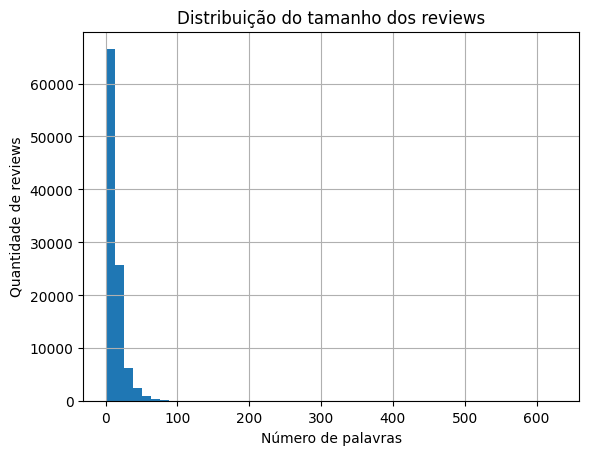

In [34]:
import matplotlib.pyplot as plt

comprimentos = X_train_clean.str.split().str.len()

print(f"Média de palavras: {comprimentos.mean():.0f}")
print(f"Mediana: {comprimentos.median():.0f}")
print(f"90% dos textos têm até: {comprimentos.quantile(0.9):.0f} palavras")
print(f"Máximo: {comprimentos.max():.0f} palavras")

comprimentos.hist(bins=50)
plt.xlabel('Número de palavras')
plt.ylabel('Quantidade de reviews')
plt.title('Distribuição do tamanho dos reviews')
plt.show()

In [ ]:
!pip install transformers -q

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print(le.classes_)

['negativo' 'neutro' 'positivo']


In [36]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('neuralmind/bert-base-portuguese-cased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [37]:
def tokenizar(textos, tokenizer, max_length=64):
    return tokenizer(
        list(textos),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

print("Tokenizando treino...")
train_enc = tokenizar(X_train_clean, tokenizer)

print("Tokenizando teste...")
test_enc  = tokenizar(X_test_clean, tokenizer)

print("Concluído!")

Tokenizando treino...
Tokenizando teste...
Concluído!


In [38]:
import torch
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    train_enc['input_ids'],
    train_enc['attention_mask'],
    torch.tensor(y_train_enc)
)

test_dataset = TensorDataset(
    test_enc['input_ids'],
    test_enc['attention_mask'],
    torch.tensor(y_test_enc)
)

print(f"Treino: {len(train_dataset)} amostras")
print(f"Teste:  {len(test_dataset)} amostras")

Treino: 103080 amostras
Teste:  25770 amostras


In [39]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    'neuralmind/bert-base-portuguese-cased',
    num_labels=3
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Modelo rodando em: {device}")

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

Modelo rodando em: cuda


In [40]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Batches de treino: {len(train_loader)}")
print(f"Batches de teste:  {len(test_loader)}")

Batches de treino: 3222
Batches de teste:  806


In [41]:
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

epochs = 3
optimizer = AdamW(model.parameters(), lr=2e-5)

total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

In [42]:
from sklearn.metrics import f1_score
import numpy as np

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids, attention_mask, labels = [b.to(device) for b in batch]

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()
        scheduler.step()

    avg_loss = total_loss / len(train_loader)


    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='weighted')
    print(f"Época {epoch+1}/{epochs} — Loss: {avg_loss:.4f} — F1: {f1:.4f}")

print("\nTreino concluído!")

Época 1/3 — Loss: 0.4588 — F1: 0.8276
Época 2/3 — Loss: 0.3599 — F1: 0.8388
Época 3/3 — Loss: 0.3025 — F1: 0.8433

Treino concluído!


In [43]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=le.classes_
))

              precision    recall  f1-score   support

    negativo       0.88      0.91      0.89      6741
      neutro       0.48      0.32      0.39      3196
    positivo       0.89      0.94      0.91     15833

    accuracy                           0.85     25770
   macro avg       0.75      0.72      0.73     25770
weighted avg       0.84      0.85      0.84     25770



In [ ]:
!pip install transformers-interpret -q

In [46]:
from transformers_interpret import SequenceClassificationExplainer

explainer = SequenceClassificationExplainer(
    model,
    tokenizer
)

In [47]:
# Pega um exemplo real de cada classe
exemplo_positivo = X_test_clean[y_test[y_test == 'positivo'].index[0]]
exemplo_negativo = X_test_clean[y_test[y_test == 'negativo'].index[0]]
exemplo_neutro   = X_test_clean[y_test[y_test == 'neutro'].index[0]]

print("Positivo:", exemplo_positivo)
print("Negativo:", exemplo_negativo)
print("Neutro:",   exemplo_neutro)

Positivo: gostei aparelho robusto elegante não grande pouco pesado apenas poderia leve câmera traseira dianteira excelentes dão show aplicativos samsung ótimos recomendo
Negativo: produto não atendeu expectativapois sistema operacional diferente usual realidade porém solicitaram troca
Neutro: produto conforme descrição super bonita recomendo


In [48]:
word_attributions = explainer(exemplo_positivo)
explainer.visualize()

In [49]:
word_attributions = explainer(exemplo_negativo)
explainer.visualize()

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
0,LABEL_0 (0.97),LABEL_0,2.00,[CLS] produto não atende ##u expectativa ##pois sistema operacional diferente usual realidade porém solic ##itaram troca [SEP]


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
0,LABEL_0 (0.97),LABEL_0,2.00,[CLS] produto não atende ##u expectativa ##pois sistema operacional diferente usual realidade porém solic ##itaram troca [SEP]


In [50]:
word_attributions = explainer(exemplo_neutro)
explainer.visualize()

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
2,LABEL_2 (0.94),LABEL_2,2.22,[CLS] produto conforme descrição super bonita recomend ##o [SEP]


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
2,LABEL_2 (0.94),LABEL_2,2.22,[CLS] produto conforme descrição super bonita recomend ##o [SEP]
